# 7장. 그래프로 데이터의 이야기를 보여주기


## 제출 정보
- 이름: 유은송
- GitHub ID: song-03
- 작성일: 2026.09.
- 최종 Notebook URL:  ??? 이거 과제 ipynb는 all status고 블로그는 completed 기준인데 뭘 기준으로 작성해야 하는지..? ipynb 따라서 하면 되나?

In [86]:
import sys
print(sys.executable)

c:\dev\llm-data-analysis-course\.venv\Scripts\python.exe


## 0. 이 노트북 사용 방법

아래 셀을 위에서부터 차례대로 실행하세요.

- 이 노트북은 5장에서 만든 `data/processed/*_clean.csv` 파일을 사용합니다.
- 전처리 파일이 없다면 먼저 `python scripts/preprocess_data.py`를 실행하세요.
- 그래프 파일은 `reports/figures/` 폴더에 저장합니다.
- 그래프 해석에서는 관찰과 원인 가설을 반드시 구분합니다.


## 1. 시각화는 분석 질문에서 시작된다

좋은 시각화는 그래프 종류를 많이 아는 데서 시작하지 않습니다. 먼저 어떤 질문에 답하려는지 정해야 합니다.

| 분석 목적 | 적합한 그래프 | 예시 질문 |
|---|---|---|
| 범주별 크기 비교 | 막대그래프 | 카테고리별 매출은 어떻게 다른가? |
| 시간 흐름 확인 | 선 그래프 | 월별 매출은 어떻게 변하는가? |
| 값의 분포 확인 | 히스토그램 | 상품 가격은 어떤 범위에 몰려 있는가? |
| 두 변수 관계 확인 | 산점도 | 가격과 판매 수량은 관계가 있는가? |
| 상위 항목 비교 | 가로 막대그래프 | 구매 금액 상위 고객은 누구인가? |
| 비율 비교 | 막대그래프 또는 파이 차트 | 주문 상태별 비중은 어떻게 되는가? |


## 2. 이번 장에서 만들 그래프

이번 장에서는 6장 EDA에서 만든 질문을 그래프로 표현합니다.

| 시각화 질문 | 사용할 데이터 | 그래프 |
|---|---|---|
| 1. 카테고리별 매출은 어떻게 다른가? | `category_sales` | 막대그래프 |
| 2. 월별 매출은 어떻게 변하는가? | `monthly_sales` | 선 그래프 |
| 3. 상품 가격은 어떤 구간에 몰려 있는가? | `products` | 히스토그램 |
| 4. 상품 가격과 판매 수량은 관계가 있는가? | `product_sales` | 산점도 |
| 5. 구매 금액 상위 고객은 누구인가? | `customer_sales` | 가로 막대그래프 |
| 6. 주문 상태별 주문 수는 어떻게 다른가? | `orders` | 막대그래프 |


## 1. 시각화 질문과 그래프 선택
| 질문 | 선택한 그래프 | 선택 이유 |
| --- | --- | --- |
| 카테고리별 completed 주문 기준 금액은 어떻게 다른가? | 막대그래프 | 같은 completed 주문 범위에서 카테고리별 매출 규모를 비교하기에 적합하다. 파이 차트보다 7개 카테고리의 실제 금액 차이와 순서를 한눈에 확인하기 쉽다. |
| 월별 completed 주문 기준 금액은 어떻게 변하는가? | 선그래프 | 2025-07부터 2026-07까지 월별 매출 변화를 시간 순서대로 확인할 수 있다. 각 월을 따로 보여주는 막대그래프보다 매출이 어느 시점에서 늘고 줄었는지 흐름을 파악하기 쉽다. |
| 상품 가격은 어떤 구간에 몰려 있는가? | 히스토그램 | 가격이 어느 구간에 많이 모여 있는지, 분포의 꼬리가 어떻게 나타나는지, 극단값 후보가 있는지 확인하기에 적합하다.|

1. 질문: 카테고리별 completed 주문 기준 금액은 어떻게 다른가? - 대표질문
- 분석 대상: completed 주문에 포함된 상품별 주문 데이터
- 분석 범위: 카테고리별 completed 주문 금액
- 사용할 지표: category, total_sales
- 선택한 그래프: 막대그래프
- 선택 이유: 같은 completed 주문 범위에서 카테고리별 금액을 바로 비교할 수 있다. 금액이 큰 카테고리와 작은 카테고리의 순서와 차이도 확인하기 쉽다.

2. 질문: 월별 completed 주문 기준 금액은 어떻게 변하는가? - 대표질문
- 분석 대상: completed 주문 데이터
- 분석 범위: 2025-07부터 2026-07까지 월별 completed 주문 금액
- 사용할 지표: order_month, total_sales
- 선택한 그래프: 선그래프
- 선택 이유: 시간 순서에 따라 금액이 어떻게 늘고 줄었는지 확인할 수 있다. 변화가 큰 시점도 찾기 쉽다. 막대그래프보다 전체적인 흐름을 보는 데 적합하다.

3. 질문: 상품 가격은 어떤 구간에 몰려 있는가? - 대표 질문
- 분석 대상: 전체 상품 데이터
- 분석 범위: 상품별 가격 분포
- 사용할 지표: price
- 선택한 그래프: 히스토그램
- 선택 이유: 상품 가격을 일정한 구간으로 나누어 각 가격대에 상품이 얼마나 있는지 확인할 수 있다. 상품이 많이 몰린 구간과 상대적으로 적은 구간도 함께 볼 수 있다.


4. 질문: 상품 가격과 판매 수량은 어떤 관계가 있는가?

- 분석 대상: completed 주문에 포함된 상품별 판매 데이터
- 분석 범위: 상품별 가격과 누적 판매 수량
- 사용할 지표: price, total_quantity
- 선택한 그래프: 산점도
- 선택 이유: 가격과 판매 수량의 관계를 한 번에 확인할 수 있다. 값이 많이 모인 구간과 가격 또는 판매 수량이 유독 높은 상품도 함께 볼 수 있다.

5. 질문: 구매 금액이 높은 고객은 누구인가?

- 분석 대상: completed 주문의 고객별 구매 데이터
- 분석 범위: 누적 구매 금액 상위 10명
- 사용할 지표: total_sales, order_count
- 선택한 그래프: 가로 막대그래프
- 선택 이유: 고객별 구매 금액을 큰 순서대로 비교하기 쉽다. 고객 ID도 세로 막대그래프보다 읽기 편하다. 

6. 질문: 주문 상태별 주문 수는 어떻게 다른가?
- 분석 대상: 전체 주문 데이터
- 분석 범위: completed, cancelled, refunded 주문
- 사용할 지표: order_count
- 선택한 그래프: 막대그래프
- 선택 이유: 상태별 주문 건수를 바로 비교할 수 있다. completed, cancelled, refunded 주문이 각각 어느 정도인지 확인하기 쉽다.

## 3. 패키지와 경로 설정

노트북이 `notebooks/` 폴더 안에서 실행되는 경우와 프로젝트 루트에서 실행되는 경우를 모두 고려해 경로를 설정합니다.


In [87]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == 'notebooks':
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
REPORT_DIR = PROJECT_ROOT / 'reports'
FIGURE_DIR = REPORT_DIR / 'figures'

REPORT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('현재 실행 위치:', CURRENT_DIR)
print('프로젝트 루트:', PROJECT_ROOT)
print('전처리 데이터 폴더:', PROCESSED_DIR)
print('그래프 저장 폴더:', FIGURE_DIR)


현재 실행 위치: c:\dev\llm-data-analysis-course\notebooks
프로젝트 루트: c:\dev\llm-data-analysis-course
전처리 데이터 폴더: c:\dev\llm-data-analysis-course\data\processed
그래프 저장 폴더: c:\dev\llm-data-analysis-course\reports\figures


## 4. 한글 폰트 설정

matplotlib에서 한글 제목이나 축 이름을 사용하면 글자가 깨질 수 있습니다. Windows 환경에서는 보통 `Malgun Gothic`을 사용합니다. Mac은 `AppleGothic`, Linux는 `NanumGothic`을 사용할 수 있습니다.


In [88]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('matplotlib 한글 폰트 설정 완료')


matplotlib 한글 폰트 설정 완료


## 5. 전처리 데이터 불러오기

7장은 5장에서 저장한 전처리 데이터를 사용합니다. 파일이 없다면 터미널에서 `python scripts/preprocess_data.py`를 먼저 실행하세요.


In [89]:
required_files = [
    PROCESSED_DIR / 'customers_clean.csv',
    PROCESSED_DIR / 'products_clean.csv',
    PROCESSED_DIR / 'orders_clean.csv',
    PROCESSED_DIR / 'order_items_clean.csv',
]

missing_files = [path for path in required_files if not path.exists()]
if missing_files:
    for path in missing_files:
        print('누락 파일:', path)
    raise FileNotFoundError('전처리 파일이 없습니다. 먼저 python scripts/preprocess_data.py 를 실행하세요.')

customers = pd.read_csv(PROCESSED_DIR / 'customers_clean.csv')
products = pd.read_csv(PROCESSED_DIR / 'products_clean.csv')
orders = pd.read_csv(PROCESSED_DIR / 'orders_clean.csv')
order_items = pd.read_csv(PROCESSED_DIR / 'order_items_clean.csv')

print('전처리 데이터 불러오기 완료')


전처리 데이터 불러오기 완료


In [90]:
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')

if 'order_month' not in orders.columns:
    orders['order_month'] = orders['order_date'].dt.to_period('M').astype(str)

if 'line_total' not in order_items.columns:
    order_items['line_total'] = order_items['quantity'] * order_items['unit_price']

print('customers:', customers.shape)
print('products:', products.shape)
print('orders:', orders.shape)
print('order_items:', order_items.shape)


customers: (150, 6)
products: (100, 4)
orders: (300, 7)
order_items: (764, 6)


## 6. 시각화를 위한 집계 데이터 만들기

그래프를 그리기 전에 필요한 집계표를 만듭니다. 대부분의 시각화는 원본 데이터를 바로 그리기보다, 질문에 맞게 요약한 표를 만든 뒤 그립니다.


In [91]:
sales_items = order_items.merge(
    products,
    on='product_id',
    how='left',
)

print('병합 전 order_items:', order_items.shape)
print('병합 후 sales_items:', sales_items.shape)
print('카테고리 누락:', sales_items['category'].isna().sum())

sales_items.head()


병합 전 order_items: (764, 6)
병합 후 sales_items: (764, 9)
카테고리 누락: 0


,order_item_id,order_id,product_id,quantity,unit_price,line_total,product_name,category,price
0,1,1,100,3,102000,306000,도서 상품 100,도서,102000
1,2,1,87,5,25000,125000,도서 상품 087,도서,25000
2,3,1,7,3,142000,426000,도서 상품 007,도서,142000
3,4,1,9,3,193000,579000,스포츠 상품 009,스포츠,193000
4,5,2,72,4,189000,756000,뷰티 상품 072,뷰티,189000


In [92]:
category_sales = (
    sales_items
    .groupby('category', as_index=False)
    .agg(
        total_quantity=('quantity', 'sum'),
        total_sales=('line_total', 'sum'),
    )
    .sort_values('total_sales', ascending=False)
)

category_sales['sales_ratio'] = (
    category_sales['total_sales'] / category_sales['total_sales'].sum() * 100
).round(2)

category_sales


,category,total_quantity,total_sales,sales_ratio
3,스포츠,468,50174000,19.63
1,뷰티,376,47551000,18.60
5,전자기기,401,41003000,16.04
2,생활용품,390,34839000,13.63
4,식품,240,33597000,13.14
0,도서,238,24645000,9.64
6,패션,220,23801000,9.31


In [93]:
order_sales = order_items.merge(
    orders,
    on='order_id',
    how='left',
)

order_sales['order_date'] = pd.to_datetime(order_sales['order_date'], errors='coerce')
order_sales['order_month'] = order_sales['order_date'].dt.to_period('M').astype(str)

monthly_sales = (
    order_sales
    .groupby('order_month', as_index=False)
    .agg(
        total_sales=('line_total', 'sum'),
        order_count=('order_id', 'nunique'),
    )
    .sort_values('order_month')
)

monthly_sales


,order_month,total_sales,order_count
0,2025-07,11827000,15
1,2025-08,21134000,24
2,2025-09,19275000,23
3,2025-10,38555000,39
4,2025-11,19961000,23
5,2025-12,21909000,26
6,2026-01,22002000,29
7,2026-02,22953000,29
8,2026-03,21646000,21
9,2026-04,23112000,31


In [94]:
product_sales = (
    sales_items
    .groupby(['product_id', 'product_name', 'category', 'price'], as_index=False)
    .agg(
        total_quantity=('quantity', 'sum'),
        total_sales=('line_total', 'sum'),
    )
    .sort_values('total_sales', ascending=False)
)

product_sales.head()


,product_id,product_name,category,price,total_quantity,total_sales
57,58,식품 상품 058,식품,197000,59,11623000
98,99,뷰티 상품 099,뷰티,200000,38,7600000
40,41,스포츠 상품 041,스포츠,163000,42,6846000
71,72,뷰티 상품 072,뷰티,189000,36,6804000
70,71,전자기기 상품 071,전자기기,161000,41,6601000


In [95]:
customer_sales_base = order_sales.merge(
    customers,
    on='customer_id',
    how='left',
)

group_columns = ['customer_id', 'city']
if 'name' in customer_sales_base.columns:
    group_columns = ['customer_id', 'name', 'city']

customer_sales = (
    customer_sales_base
    .groupby(group_columns, as_index=False)
    .agg(
        order_count=('order_id', 'nunique'),
        total_sales=('line_total', 'sum'),
    )
    .sort_values('total_sales', ascending=False)
)

customer_sales['avg_order_value'] = (
    customer_sales['total_sales'] / customer_sales['order_count']
).round(0)

customer_sales.head()


,customer_id,name,city,order_count,total_sales,avg_order_value
79,102,이진호,고양,5,5977000,1195400.0
93,117,김지원,성남,6,5552000,925333.0
67,83,전은경,수원,5,4951000,990200.0
118,142,하서연,서울,3,4862000,1620667.0
34,40,박예준,서울,5,4857000,971400.0


In [96]:
order_status = orders['order_status'].value_counts(dropna=False).reset_index()
order_status.columns = ['order_status', 'order_count']
order_status


,order_status,order_count
0,completed,184
1,cancelled,64
2,refunded,52


## 7. 카테고리별 매출 막대그래프

카테고리별 매출은 범주별 크기 비교이므로 막대그래프가 적합합니다. 그래프는 화면에 표시하고 동시에 PNG 파일로 저장합니다.


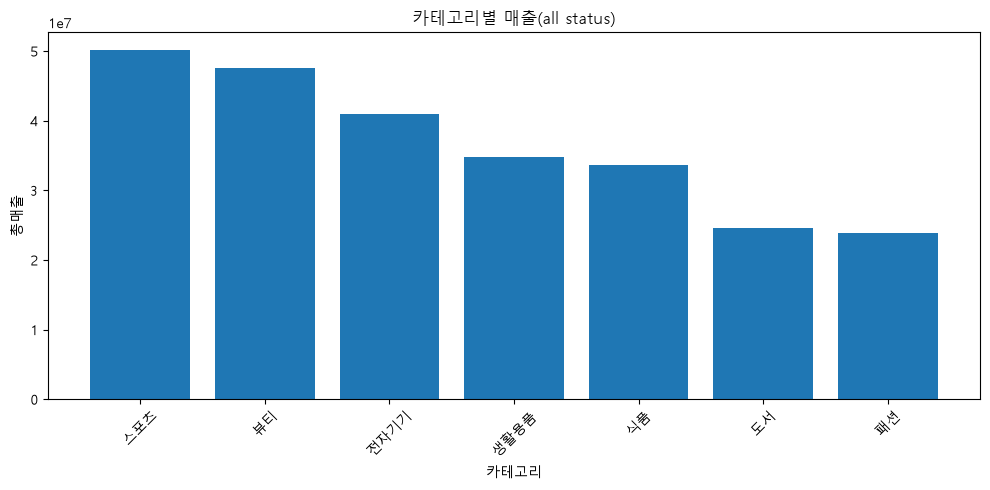

In [97]:
plt.figure(figsize=(10, 5))
plt.bar(category_sales['category'], category_sales['total_sales'])
plt.title('카테고리별 매출(all status)')
plt.xlabel('카테고리')
plt.ylabel('총매출')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'ch07_category_sales_bar.png', dpi=150, bbox_inches='tight')
plt.show()


해석 예시:

> 관찰: 카테고리별 매출 크기가 서로 다르게 나타납니다.
> 가설: 매출 차이는 판매 수량 또는 평균 단가 차이에서 비롯되었을 수 있습니다.
> 추가 분석: 카테고리별 판매 수량과 평균 단가를 함께 확인해야 합니다.


## 2. 대표 그래프 1
![대표 그래프 1](images/graph01.png)

### 원본 집계값
category_sales['category'], category_sales['total_sales']
| 카테고리 | 판매 수량 | 주문 기준 금액 | 비중 |
|---|---:|---:|---:|
| 스포츠 | 468 | 50,174,000원 | 19.63% |
| 뷰티 | 376 | 47,551,000원 | 18.60% |
| 전자기기 | 401 | 41,003,000원 | 16.04% |
| 생활용품 | 390 | 34,839,000원 | 13.63% |
| 식품 | 240 | 33,597,000원 | 13.14% |
| 도서 | 238 | 24,645,000원 | 9.64% |
| 패션 | 220 | 23,801,000원 | 9.31% |

### 결과 관찰
x축을 카테고리, y축을 총매출로 하여 막대그래프로 시각화되었다(기준=all status). 주문기준 금액이 큰 순서대로 스포츠, 뷰티, 전자기기, 생활용품, 식품, 도서, 패션이었다. 스포츠가 50,174,000원으로 가장 컸고 패션은 23,801,000원으로 가장 작았다. 두 카테고리의 차이는 26373000이며 스포츠 금액은 패션의 약 2.1배였다.  막대그래프는 금액이 큰 순서대로 정렬했고 값 축은 0부터 시작하도록 설정했다. 단위는 원이었으나 수학적 기호 e를 반영해 표시되었다. 정렬은 총매출이 높은 순대로 정렬되었다. 

### 나의 해석과 판단
막대그래프로 시각화하니 어떤 카테고리가 가장 주문 기준 금액이 크고 작은지 순서대로 한 눈에 파악하기 좋았다. 다만 막대그래프로 나타냈기 때문에 어떤 것이 비중이 큰지, 혹은 실제 값이 몇인지는 들어오지 않아 해석하기 힘들었다. 스포츠가 가장 주문 금액이 많으므로 스포츠가 가장 인기 품목이라고 생각할 수 있으나, 판매 수량까지 포함해서 판단해야 한다. 스포츠는 판매 수량 및 금액 모두 가장 높으므로 그럴 가능성이 높지만, 나머지 품목들에도 일괄적으로 적용해서는 안된다고 생각한다.

### 업무·분석적 의미
카테고리별 주문 금액을 막대그래프로 비교하면 여러 카테고리의 규모와 순서를 빠르게 확인할 수 있다. MD나 판매 담당자는 이 결과를 바탕으로 어떤 카테고리를 먼저 점검할지 정할 수 있다. 재고, 상품 구성, 프로모션 관련 추가 분석 대상을 고르는 데도 활용할 수 있다. 보고를 받는 사람도 원본 표를 하나씩 확인하지 않고 카테고리별 금액 차이를 바로 볼 수 있다. 

### 한계와 추가 확인 사항

이번 그래프는 전체 sales_items 데이터를 기준으로 카테고리별 주문 금액을 비교했다. 따라서 completed뿐 아니라 cancelled, refunded 주문이 포함되어 있을 수 있다. 이 금액을 최종 확정 매출이라고 보기는 어렵다. 또한 금액 차이만으로 카테고리별 차이가 왜 발생했는지는 알 수 없다. 판매 수량이 많아서인지, 상품 가격이 높아서인지, 일부 고가 상품의 영향인지 따로 확인해야 한다. 추가로 카테고리별 주문 수, 판매 수량, 평균 상품 가격, 평균 주문금액을 확인할 필요가 있다. 주문 상태별 금액과 월별 변화도 함께 비교한다.

## 8. 월별 매출 선 그래프

월별 매출은 시간 흐름을 보는 문제이므로 선 그래프가 적합합니다. x축 순서가 월 순서대로 정렬되어 있어야 합니다.


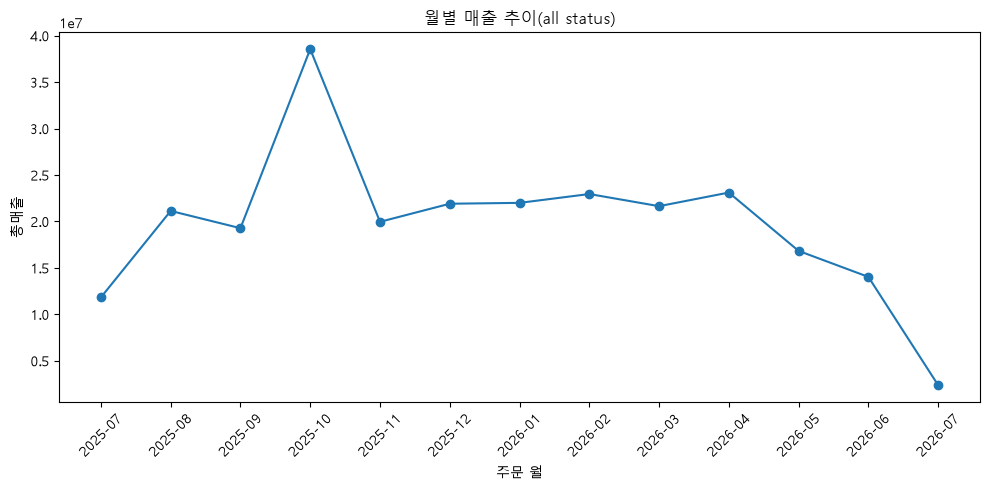

In [98]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['order_month'], monthly_sales['total_sales'], marker='o')
plt.title('월별 매출 추이(all status)')
plt.xlabel('주문 월')
plt.ylabel('총매출')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'ch07_monthly_sales_line.png', dpi=150, bbox_inches='tight')
plt.show()


월별 매출이 증가하거나 감소해도 그 원인을 바로 단정하면 안 됩니다. 주문 수, 평균 주문 금액, 프로모션 여부, 특정 카테고리 매출 변화를 추가로 확인해야 합니다.


## 3. 대표 그래프 2
![대표 그래프 2](images/graph02.png)

### 원본 집계값
monthly_sales['order_month'], monthly_sales['total_sales']
| 주문 월 | 주문 기준 금액 | 주문 수 |
|---|---:|---:|
| 2025-07 | 11,827,000원 | 15 |
| 2025-08 | 21,134,000원 | 24 |
| 2025-09 | 19,275,000원 | 23 |
| 2025-10 | 38,555,000원 | 39 |
| 2025-11 | 19,961,000원 | 23 |
| 2025-12 | 21,909,000원 | 26 |
| 2026-01 | 22,002,000원 | 29 |
| 2026-02 | 22,953,000원 | 29 |
| 2026-03 | 21,646,000원 | 21 |
| 2026-04 | 23,112,000원 | 31 |
| 2026-05 | 16,829,000원 | 20 |
| 2026-06 | 14,031,000원 | 16 |
| 2026-07 | 2,376,000원 | 4 |

### 결과 관찰
x축을 주문 월, y축을 총매출로 하여 (기준=all status) 꺾은선 그래프로 시각화되었다. 중간에 빠진 월은 없었으며, 월 순서도 올발랐다. 날짜 변환은 모두 된 것으로 보이며(이전 실습에서 확인되었음), 값이 없는 월이나 0인 월은 없었다. 주문 월별 총매출 추이를 분석한 결과, 가장 월매출이 높았던 것은 2025년 10월 38,555,000원이었다. 가장 울매출이 낮았던 것은 2026년 7월 2,376,000원이었다. 2025년 11월부터 2026년 4월까지는 완만하게 증가하는 추세를 보였으나(2026년 3월에는 약간 감소), 2026년 5월부터 감소하였다. 따라서 일시적인 완만한 증가와 감소가 관찰되었다. 날짜 정렬은 시간순대로 되었으며, 누락기간은 관찰되지 않았다. 축 범위는 2025년 7월~2026년 7월이었다. 

### 나의 해석과 판단
꺾은선 그래프로 월별 추이를 확인하니 한눈에 월별 추이 변화를 파악할 수 있었다. 또한 언제 피크를 찍었는지 역시 쉽게 확인할 수 있었다. 분석 결과 2025년 10월이 가장 높았는데, 이떄 주문 건수도 39건으로 가장 많아 납득되는 결과였다. 반면 2025년 7월과 2026년 7월은 낮았는데, 이는 해당 월이 전체 한달을 반영한 것이 아니기 때문일 가능성이 높다. 또한 이 추이만을 가지고는 트렌드 변화를 분석하기 어렵다. 오직 1년의 결과일뿐이므로, 월별 추이에 대한 일반적인 경향성을 내놓기 위해서는 최소 2개년 이상의 데이터가 필요하다. 

### 업무·분석적 의미
꺾은선 그래프를 사용하면 월별 주문 금액이 시간에 따라 어떻게 변했는지 확인할 수 있다. 어느 달의 금액이 높은지만 보는 것이 아니라 증가하거나 감소한 시점과 변화 폭이 큰 달도 찾을 수 있다.예를 들어 2025년 10월처럼 금액이 크게 증가한 달은 주문 수, 평균 주문금액, 카테고리 구성을 추가로 확인할 대상으로 볼 수 있다. 금액이 감소한 달도 같은 지표를 비교해 어떤 차이가 함께 나타났는지 확인할 수 있다.업무에서는 월별 실적 변화를 확인하고 이후 분석이 필요한 시점을 정하는 데 활용할 수 있다. 주문 금액과 주문 수를 함께 비교하면 두 지표가 비슷하게 움직이는지도 볼 수 있다. 

### 한계와 추가 확인 사항
선 그래프는 시간에 따른 변화를 보여줄 뿐이지 변화가 발생한 원인까지 설명하지는 않는다. 프로모션, 재고, 상품 구성, 판매 기간, 계절성에 대한 정보는 현재 집계에 없으므로 원인으로 판단할 수 없다. 첫 달과 마지막 달이 한 달 전체를 포함하는지도 이 월별 표만으로 확인하기 어렵다(이는 이전 실습들의 결과로 내가 파악하고 있는 사항이다).

## 9. 상품 가격 분포 히스토그램

히스토그램은 숫자형 데이터가 어느 구간에 많이 몰려 있는지 보여줍니다. 상품 가격 분포를 보면 저가/중가/고가 상품이 어떻게 분포하는지 확인할 수 있습니다.


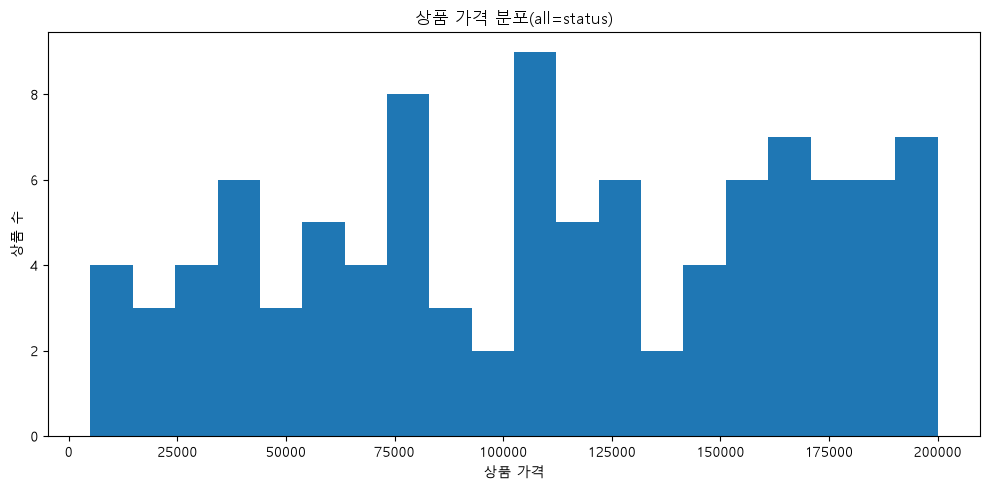

In [99]:
plt.figure(figsize=(10, 5))
plt.hist(products['price'], bins=20)
plt.title('상품 가격 분포(all=status)')
plt.xlabel('상품 가격')
plt.ylabel('상품 수')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'ch07_product_price_hist.png', dpi=150, bbox_inches='tight')
plt.show()


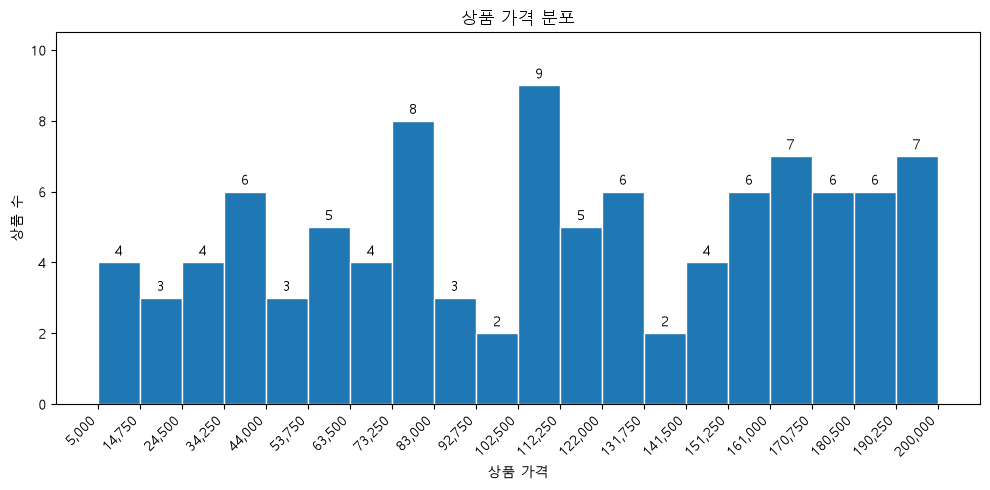

In [100]:
fig, ax = plt.subplots(figsize=(10, 5))

counts, bin_edges, bars = ax.hist(
    products['price'],
    bins=20,
    edgecolor='white',
)

# 각 막대 위에 y값(상품 수) 표시
ax.bar_label(
    bars,
    labels=[str(int(count)) for count in counts],
    padding=3,
)

# bins=20의 모든 가격 구간 경계값을 x축에 표시
ax.set_xticks(bin_edges)
ax.set_xticklabels(
    [f'{price:,.0f}' for price in bin_edges],
    rotation=45,
    ha='right',
)

ax.set_title('상품 가격 분포')
ax.set_xlabel('상품 가격')
ax.set_ylabel('상품 수')
ax.set_ylim(0, counts.max() + 1.5)  # 막대 위 숫자가 잘리지 않도록 여백 추가

plt.tight_layout()
plt.show()

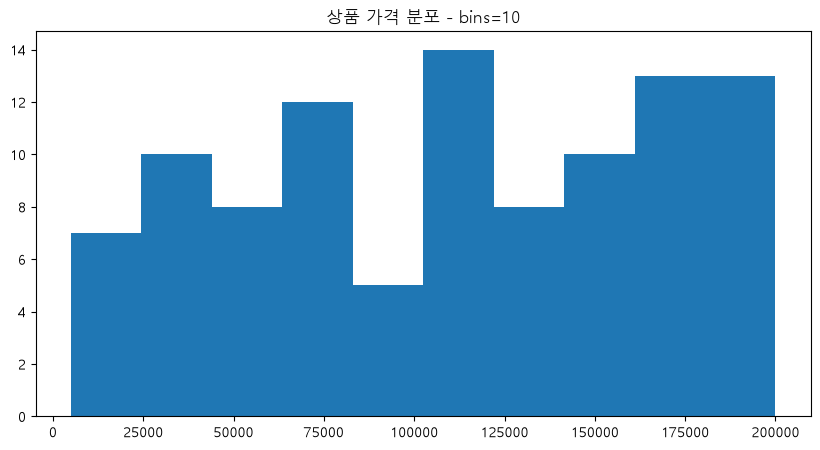

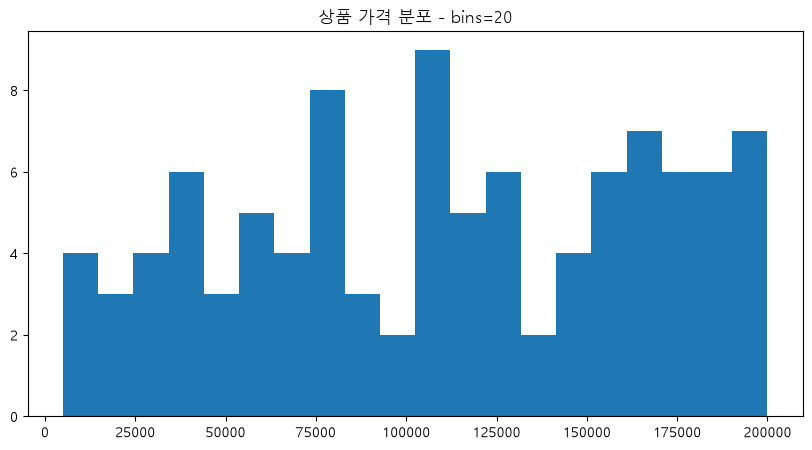

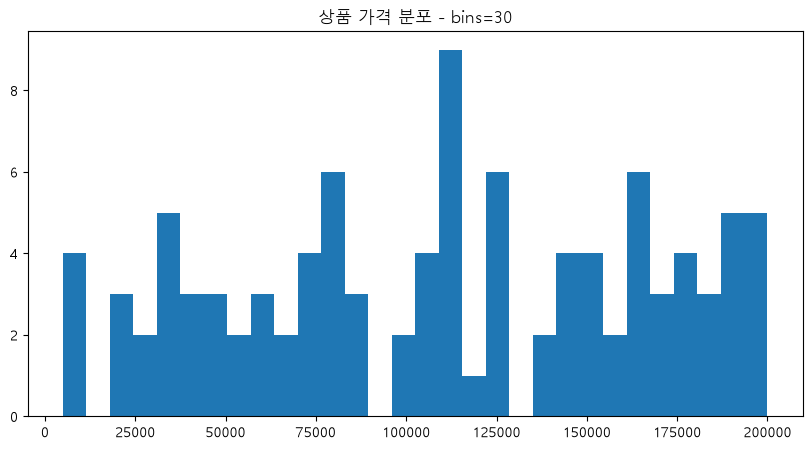

In [101]:

for bins in [10, 20, 30]:

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.hist(products["price"], bins=bins)

    ax.set_title(f"상품 가격 분포 - bins={bins}")

    plt.show()


## 4. 대표 그래프 3
![대표 그래프 3](images/graph03.png)

### 원본 집계값
products['price']
(데이터가 많아 5개만 예시를 위해 표로 첨부함)
### 총 주문 기준 금액 상위 5개 상품
| 58 | 식품 상품 058 | 식품 | 197,000원 | 59 | 11,623,000원 |
| 99 | 뷰티 상품 099 | 뷰티 | 200,000원 | 38 | 7,600,000원 |
| 41 | 스포츠 상품 041 | 스포츠 | 163,000원 | 42 | 6,846,000원 |
| 72 | 뷰티 상품 072 | 뷰티 | 189,000원 | 36 | 6,804,000원 |
| 71 | 전자기기 상품 071 | 전자기기 | 161,000원 | 41 | 6,601,000원 |

### 결과 관찰
x축을 상품가격, y축을 상품수로 하여 히스토그램으로 시각화되었다. 값은 5000원~200000원 범위에 분포하였으며, 102500~112250원 범위에 9개로 가장 많이 분포하였고, 92750~102500원, 131750~141500원 범위에 2개로 가장 적게 분포하였다. 또한 bins를 10, 20, 30 으로 바꿔가며 히스토그램을 시각화한 결과 전체적인 분포 경향성이 유지되었다. 긴 꼬리는 없었다. 

### 나의 해석과 판단
상품 가격은 특정 한 구간에만 몰려 있기보다는 낮은 가격부터 높은 가격까지 비교적 넓게 퍼져 있는 형태라고 판단했다. 다만 10만원대 초반과 15만원 이상 구간에 상품이 비교적 많이 분포했다. 10만원대 초반과 15만원 이상 구간에도 상품이 꾸준히 있어 고가 상품이 일부만 존재하는 구성은 아니었다. 반면 9만원대에서 10만원대 초반, 13만원대에서 14만원대 초반은 주변 구간보다 상품 수가 적었다. 다만 이 차이가 가격 정책 때문인지, 카테고리별 가격 차이 때문인지는 현재 그래프만으로 알 수 없다고 생각했다. 극단값 역시 관찰되지 않는다고 봤다. 최소가 2, 최대가 9인데 그 근처(ex. 각각 3, 7)에도 분포하는 값이 있기 때문에 없다고 판단헀으며, 따라서 이에 대한 추가적인 확인이 필요하지는 않다고 생각했다.

### 업무·분석적 의미
히스토그램을 보면 상품이 어느 가격대에 많이 분포하는지, 어느 구간에 상품 수가 적은지 확인하기 쉽다. 상품 기획이나 MD 업무에서는 현재 상품의 가격 구성이 어떻게 되어 있는지 살펴보는 기초 자료로 사용할 수 있다. 상품 수가 적은 가격대는 판매 수량이나 카테고리 구성을 추가로 확인할 대상으로 볼 수 있다. 상품 수가 많은 구간도 실제 판매가 함께 많은지 따로 확인해야 한다. bins 값을 바꿔 보면서 전체적인 분포가 비슷하게 나타나는지도 확인할 수 있다.

### 한계와 추가 확인 사항
이 그래프는 상품 가격과 각 가격 구간의 상품 수만 보여 준다. 가격대별 판매 수량이나 주문 금액은 알 수 없다. 따라서 상품이 많이 등록된 가격대가 실제로 많이 판매되었거나 매출이 높았다고 판단할 수는 없다. 이후 가격대별 판매 수량과 주문 금액을 따로 집계해 확인할 필요가 있다. 가격 구간도 bins=20 설정에 따라 달라진다. bins를 바꾸면 가장 많거나 적게 보이는 구간이 달라질 수 있다.

In [102]:
import numpy as np

# Q1. 카테고리별 주문 기준 금액 막대그래프 검증
q1_source_total = sales_items['line_total'].sum()
q1_category_total = category_sales['total_sales'].sum()

print('[Q1] 카테고리별 주문 기준 금액')
print('원본 line_total 합계:', f'{q1_source_total:,.0f}원')
print('카테고리별 total_sales 합계:', f'{q1_category_total:,.0f}원')
print('합계 일치:', 'PASS' if q1_source_total == q1_category_total else 'CHECK')
print(category_sales[['category', 'total_sales']].to_string(index=False))


# Q2. 월별 주문 기준 금액 꺾은선그래프 검증
q2_base = order_sales.dropna(subset=['order_date'])
q2_source_total = q2_base['line_total'].sum()
q2_monthly_total = monthly_sales['total_sales'].sum()
q2_month_order = monthly_sales['order_month'].tolist()

print('\n[Q2] 월별 주문 기준 금액')
print('유효한 주문일 기준 line_total 합계:', f'{q2_source_total:,.0f}원')
print('월별 total_sales 합계:', f'{q2_monthly_total:,.0f}원')
print('합계 일치:', 'PASS' if q2_source_total == q2_monthly_total else 'CHECK')
print('월 순서 오름차순:', 'PASS' if q2_month_order == sorted(q2_month_order) else 'CHECK')
print(monthly_sales[['order_month', 'total_sales', 'order_count']].to_string(index=False))


# Q3. 상품 가격 히스토그램 검증
q3_counts, q3_edges = np.histogram(products['price'], bins=20)

q3_histogram_table = pd.DataFrame({
    '가격 구간 시작': q3_edges[:-1],
    '가격 구간 끝': q3_edges[1:],
    '상품 수': q3_counts,
})

print('\n[Q3] 상품 가격 히스토그램')
print('상품 수:', len(products))
print('히스토그램 막대 상품 수 합계:', q3_counts.sum())
print('상품 수 일치:', 'PASS' if len(products) == q3_counts.sum() else 'CHECK')
print(q3_histogram_table.to_string(index=False))

[Q1] 카테고리별 주문 기준 금액
원본 line_total 합계: 255,610,000원
카테고리별 total_sales 합계: 255,610,000원
합계 일치: PASS
category  total_sales
     스포츠     50174000
      뷰티     47551000
    전자기기     41003000
    생활용품     34839000
      식품     33597000
      도서     24645000
      패션     23801000

[Q2] 월별 주문 기준 금액
유효한 주문일 기준 line_total 합계: 255,610,000원
월별 total_sales 합계: 255,610,000원
합계 일치: PASS
월 순서 오름차순: PASS
order_month  total_sales  order_count
    2025-07     11827000           15
    2025-08     21134000           24
    2025-09     19275000           23
    2025-10     38555000           39
    2025-11     19961000           23
    2025-12     21909000           26
    2026-01     22002000           29
    2026-02     22953000           29
    2026-03     21646000           21
    2026-04     23112000           31
    2026-05     16829000           20
    2026-06     14031000           16
    2026-07      2376000            4

[Q3] 상품 가격 히스토그램
상품 수: 100
히스토그램 막대 상품 수 합계: 100
상품 수 일치: PASS
 가격 구간 시작  가격

## 10. 상품 가격과 판매 수량 산점도

산점도는 두 숫자형 변수의 관계를 탐색할 때 사용합니다. 여기서는 상품 가격과 총 판매 수량 사이의 관계를 확인합니다. 산점도만으로 원인 관계를 단정해서는 안 됩니다.


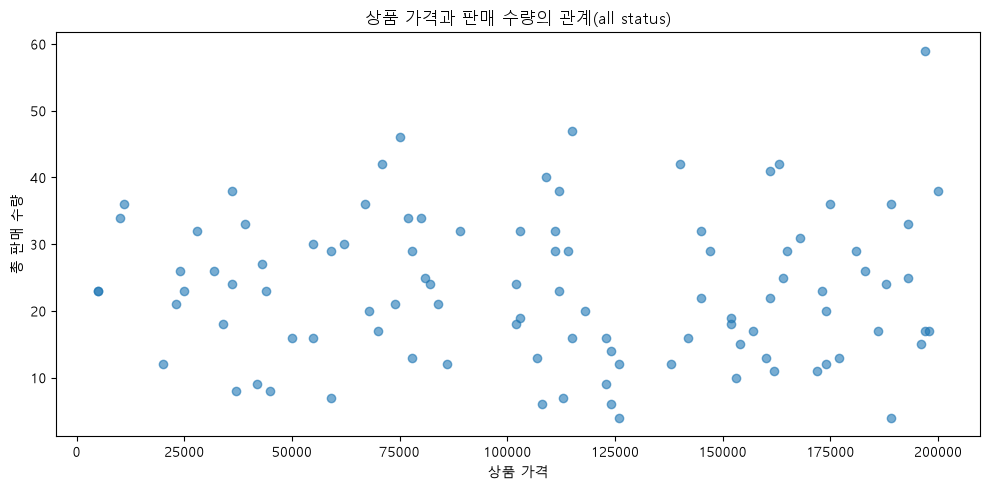

In [103]:
plt.figure(figsize=(10, 5))
plt.scatter(product_sales['price'], product_sales['total_quantity'], alpha=0.6)
plt.title('상품 가격과 판매 수량의 관계(all status)')
plt.xlabel('상품 가격')
plt.ylabel('총 판매 수량')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'ch07_price_quantity_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. 구매 금액 상위 고객 가로 막대그래프

상위 항목을 비교할 때는 가로 막대그래프가 읽기 좋습니다. 고객명은 개인정보가 될 수 있으므로 보고서에서는 익명화 라벨을 사용하는 것이 좋습니다.


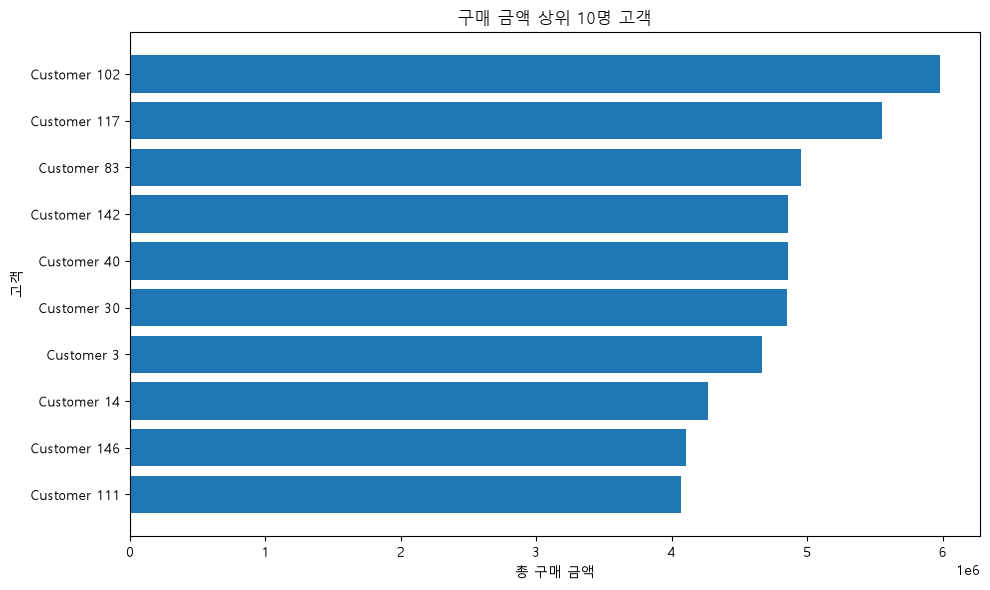

In [104]:
top_customers = customer_sales.head(10).copy()
top_customers['customer_label'] = 'Customer ' + top_customers['customer_id'].astype(str)
top_customers = top_customers.sort_values('total_sales')

plt.figure(figsize=(10, 6))
plt.barh(top_customers['customer_label'], top_customers['total_sales'])
plt.title('구매 금액 상위 10명 고객')
plt.xlabel('총 구매 금액')
plt.ylabel('고객')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'ch07_top_customers_barh.png', dpi=150, bbox_inches='tight')
plt.show()


고객별 구매 금액 상위 그래프는 우수 고객 후보를 확인하는 데 유용합니다. 하지만 한 번에 많이 구매한 고객과 여러 번 반복 구매한 고객은 구분해서 해석해야 합니다.


## 12. 주문 상태별 주문 수 막대그래프

주문 상태별 주문 수는 완료, 취소, 환불 등 주문 상태의 분포를 확인하는 데 사용합니다.


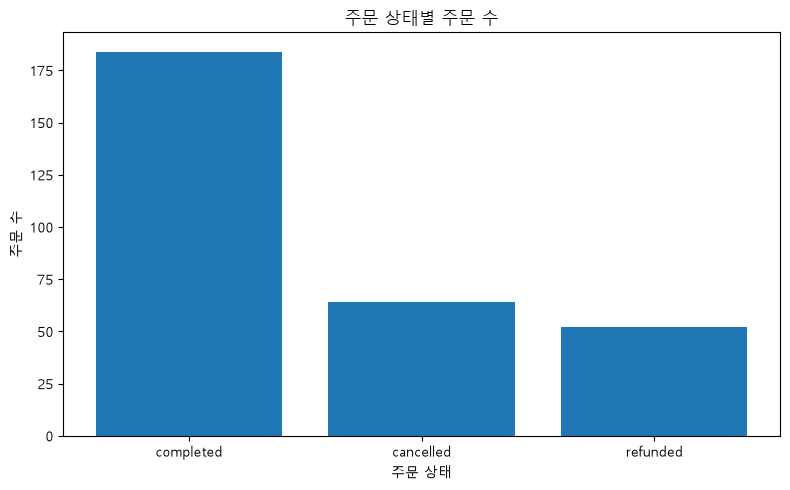

In [105]:
plt.figure(figsize=(8, 5))
plt.bar(order_status['order_status'], order_status['order_count'])
plt.title('주문 상태별 주문 수')
plt.xlabel('주문 상태')
plt.ylabel('주문 수')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'ch07_order_status_bar.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. 저장된 그래프 확인하기

생성된 그래프 파일을 확인합니다. 보고서나 발표 자료에 사용할 수 있도록 `reports/figures` 폴더에 저장했습니다.


In [106]:
list(FIGURE_DIR.glob('ch07_*.png'))


[WindowsPath('c:/dev/llm-data-analysis-course/reports/figures/ch07_assignment_category_quantity.png'),
 WindowsPath('c:/dev/llm-data-analysis-course/reports/figures/ch07_assignment_payment_method_count.png'),
 WindowsPath('c:/dev/llm-data-analysis-course/reports/figures/ch07_category_sales_bar.png'),
 WindowsPath('c:/dev/llm-data-analysis-course/reports/figures/ch07_customer_order_count_sales_scatter.png'),
 WindowsPath('c:/dev/llm-data-analysis-course/reports/figures/ch07_monthly_sales_line.png'),
 WindowsPath('c:/dev/llm-data-analysis-course/reports/figures/ch07_order_status_bar.png'),
 WindowsPath('c:/dev/llm-data-analysis-course/reports/figures/ch07_price_quantity_scatter.png'),
 WindowsPath('c:/dev/llm-data-analysis-course/reports/figures/ch07_product_price_hist.png'),
 WindowsPath('c:/dev/llm-data-analysis-course/reports/figures/ch07_top_customers_barh.png')]

## 14. 시각화 요약표 만들기

각 그래프의 목적과 해석 포인트를 표로 정리하면 이후 보고서 작성이 쉬워집니다.


In [107]:
visualization_summary = pd.DataFrame({
    'chart': [
        '카테고리별 매출 막대그래프',
        '월별 매출 선 그래프',
        '상품 가격 분포 히스토그램',
        '상품 가격과 판매 수량 산점도',
        '구매 금액 상위 고객 가로 막대그래프',
        '주문 상태별 주문 수 막대그래프',
    ],
    'question': [
        '카테고리별 매출은 어떻게 다른가?',
        '월별 매출은 어떻게 변하는가?',
        '상품 가격은 어떤 구간에 몰려 있는가?',
        '상품 가격과 판매 수량은 관계가 있는가?',
        '구매 금액이 높은 고객은 누구인가?',
        '주문 상태별 주문 수는 어떻게 다른가?',
    ],
    'interpretation_point': [
        '매출 기여도가 높은 카테고리 확인',
        '시간에 따른 증가와 감소 흐름 확인',
        '상품 가격대의 분포와 이상값 후보 확인',
        '가격과 판매 수량의 관계 탐색',
        '우수 고객 후보 확인',
        '완료, 취소 등 주문 상태 분포 확인',
    ],
    'file_name': [
        'ch07_category_sales_bar.png',
        'ch07_monthly_sales_line.png',
        'ch07_product_price_hist.png',
        'ch07_price_quantity_scatter.png',
        'ch07_top_customers_barh.png',
        'ch07_order_status_bar.png',
    ],
})

visualization_summary


,chart,question,interpretation_point,file_name
0,카테고리별 매출 막대그래프,카테고리별 매출은 어떻게 다른가?,매출 기여도가 높은 카테고리 확인,ch07_category_sales_bar.png
1,월별 매출 선 그래프,월별 매출은 어떻게 변하는가?,시간에 따른 증가와 감소 흐름 확인,ch07_monthly_sales_line.png
2,상품 가격 분포 히스토그램,상품 가격은 어떤 구간에 몰려 있는가?,상품 가격대의 분포와 이상값 후보 확인,ch07_product_price_hist.png
3,상품 가격과 판매 수량 산점도,상품 가격과 판매 수량은 관계가 있는가?,가격과 판매 수량의 관계 탐색,ch07_price_quantity_scatter.png
4,구매 금액 상위 고객 가로 막대그래프,구매 금액이 높은 고객은 누구인가?,우수 고객 후보 확인,ch07_top_customers_barh.png
5,주문 상태별 주문 수 막대그래프,주문 상태별 주문 수는 어떻게 다른가?,"완료, 취소 등 주문 상태 분포 확인",ch07_order_status_bar.png


## 15. 시각화 요약 보고서 저장하기

시각화 목적, 생성한 그래프 목록, 해석 포인트, 주의사항을 Markdown 보고서로 저장합니다.


In [108]:
summary_text = f'''# Chapter 7 데이터 시각화 요약 보고서

## 1. 시각화 목적

전처리 및 EDA 결과를 바탕으로 온라인 쇼핑몰 데이터의 주요 패턴을 그래프로 확인했습니다.

## 2. 생성한 그래프 목록

```text
{visualization_summary.to_string(index=False)}
```

## 3. 주요 해석 포인트

- 카테고리별 매출 그래프를 통해 매출 기여도가 높은 상품군을 확인할 수 있습니다.
- 월별 매출 선 그래프를 통해 시간에 따른 매출 흐름을 확인할 수 있습니다.
- 상품 가격 히스토그램을 통해 상품 가격대 분포를 확인할 수 있습니다.
- 가격과 판매 수량 산점도는 두 변수 사이의 관계를 탐색하는 데 사용합니다.
- 고객별 구매 금액 상위 그래프는 우수 고객 후보를 파악하는 데 유용합니다.
- 주문 상태별 주문 수 그래프는 완료, 취소 등 주문 상태의 분포를 확인하는 데 사용합니다.

## 4. 해석 시 주의사항

- 그래프는 데이터를 쉽게 보여주지만 원인을 자동으로 설명하지는 않습니다.
- 매출이 높은 이유는 판매 수량, 단가, 주문 수 등을 함께 확인해야 합니다.
- 고객명 등 개인정보가 포함될 수 있는 그래프는 익명화가 필요할 수 있습니다.
- 시각화 결과는 보고서에 넣기 전에 축, 제목, 단위가 명확한지 확인해야 합니다.

## 5. 다음 단계

다음 장에서는 지금까지 배운 데이터 불러오기, 전처리, EDA, 시각화를 종합하여 중간 실습 프로젝트를 수행합니다.
'''

summary_path = REPORT_DIR / 'ch07_visualization_summary.md'
summary_path.write_text(summary_text, encoding='utf-8')

print('시각화 요약 보고서 저장 완료:', summary_path)


시각화 요약 보고서 저장 완료: c:\dev\llm-data-analysis-course\reports\ch07_visualization_summary.md


## 16. 소스 모듈로 같은 시각화 실행하기

위에서 노트북으로 한 단계씩 실행한 시각화는 `src/visualization.py`에 함수로 정리되어 있습니다. 반복 실행하거나 프로젝트 코드로 관리하려면 소스 모듈을 사용하는 것이 좋습니다.


In [109]:
from src.visualization import (
    create_all_figures,
    create_visualization_summary,
    prepare_visualization_data,
    setup_korean_font,
)

setup_korean_font()
module_viz_data = prepare_visualization_data(PROCESSED_DIR)
module_viz_summary = create_visualization_summary()
module_viz_summary


,chart,question,interpretation_point,file_name
0,카테고리별 매출 막대그래프,카테고리별 매출은 어떻게 다른가?,매출 기여도가 높은 카테고리 확인,ch07_category_sales_bar.png
1,월별 매출 선 그래프,월별 매출은 어떻게 변하는가?,시간에 따른 증가와 감소 흐름 확인,ch07_monthly_sales_line.png
2,상품 가격 분포 히스토그램,상품 가격은 어떤 구간에 몰려 있는가?,상품 가격대의 분포와 이상값 후보 확인,ch07_product_price_hist.png
3,상품 가격과 판매 수량 산점도,상품 가격과 판매 수량은 관계가 있는가?,가격과 판매 수량의 관계 탐색,ch07_price_quantity_scatter.png
4,구매 금액 상위 고객 가로 막대그래프,구매 금액이 높은 고객은 누구인가?,우수 고객 후보 확인,ch07_top_customers_barh.png
5,주문 상태별 주문 수 막대그래프,주문 상태별 주문 수는 어떻게 다른가?,"완료, 취소 등 주문 상태 분포 확인",ch07_order_status_bar.png


## 17. 스크립트로 한 번에 실행하기

노트북에서 한 단계씩 이해한 시각화 과정을 스크립트로도 실행할 수 있습니다. 터미널에서 프로젝트 루트 기준으로 아래 명령을 실행합니다.

```bash
python scripts/run_visualization.py
```

이 스크립트는 7장 그래프 파일 6개와 `reports/ch07_visualization_summary.md`를 자동으로 저장합니다.


### 내가 발견한 시각화 위험 또는 개선점

- 문제: 카테고리별 막대 그래프의 금액 축에 통화나 금액 단위가 표시되지 않았다
- 왜 오해를 만들 수 있는가: 보는 사람이 숫자의 통화와 단위를 직접 추정해야 한다. 다른 자료와 비교할 때도 금액을 잘못 이해할 수 있다.
- 수정 방법: 원본 데이터에서 통화 단위를 먼저 확인한 뒤 y축 제목과 눈금에 표시한다. 확인되지 않은 통화를 임의로 넣지는 않는다.
- 수정 후 확인 결과: y축에 (백만 원)을 표기하여 오해의 소지를 줄였고, 각 막대그래프 상단에도 금액을 표기하여 오해의 소지를 줄였다.


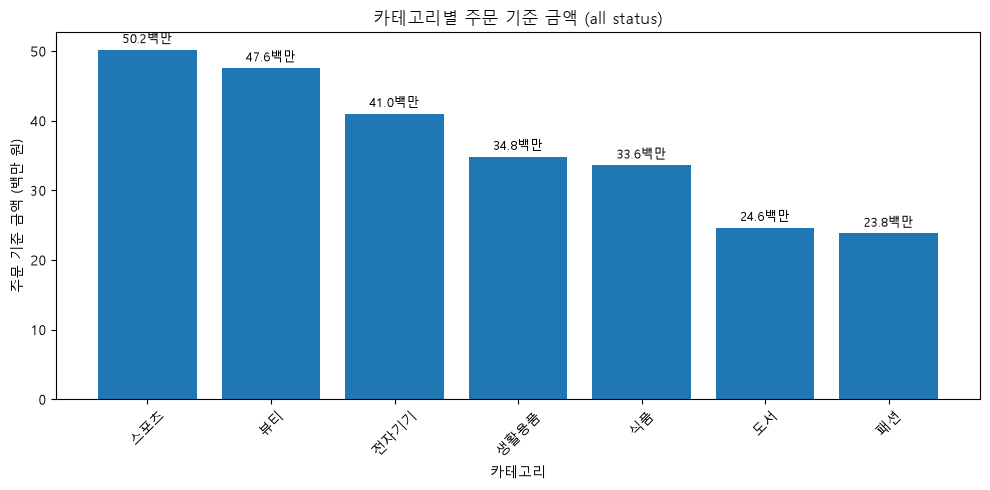

In [110]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    category_sales['category'],
    category_sales['total_sales'],
)

ax.set_title('카테고리별 주문 기준 금액 (all status)')
ax.set_xlabel('카테고리')
ax.set_ylabel('주문 기준 금액 (백만 원)')

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f'{value / 1_000_000:,.0f}')
)

ax.bar_label(
    bars,
    labels=[
        f'{value / 1_000_000:,.1f}백만'
        for value in category_sales['total_sales']
    ],
    padding=3,
    fontsize=9,
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / 'ch07_category_sales_bar.png',
    dpi=150,
    bbox_inches='tight',
)

plt.show()

## 18. LLM에게 그래프 선택과 해석 요청하기

LLM은 그래프 선택, matplotlib 코드 작성, 해석 문장 작성에 도움을 줄 수 있습니다. 하지만 그래프 해석은 반드시 실제 데이터와 비교해야 합니다.

```text
온라인 쇼핑몰 데이터에서 다음 분석 질문을 시각화하려고 합니다.

분석 질문:
1. 카테고리별 매출은 어떻게 다른가?
2. 월별 매출은 어떻게 변하는가?
3. 상품 가격은 어떤 구간에 몰려 있는가?
4. 상품 가격과 판매 수량은 관계가 있는가?
5. 구매 금액 상위 고객은 누구인가?

현재 집계표
'~'

각 질문에 적합한 그래프 종류를 추천해 주세요.
1. 각 그래프를 선택한 이유, 적절한지
2. 제목과 축 이름을 어떻게 쓰면 명확할지
3. 오해를 일으킬 수 있는 축 설정 있는지
4. 그래프만으로 단정해서는 안 되는 내용
5. 추가 검증할 수 있는 지표
를 설명해주세요. 실제 원인 만들어내지 마세요.
```



### LLM 시각화 검토

- 제공한 Safe Context: 전체 주문 상태(all status) 기준의 카테고리별·월별 주문 기준 금액 집계표, 전체 상품의 가격 구간별 상품 수 집계표, 상품 가격, 판매 수량 예시 집계표를 제공했다. 고객 이름과 도시 등 개인정보는 제외했으며, 주문 기준 금액은 취소·환불 주문을 포함할 수 있어 확정 매출로 단정할 수 없다는 분석 범위와 해석상 주의사항도 함께 제공했다.
- Prompt: 
    온라인 쇼핑몰 데이터에서 다음 분석 질문을 시각화하려고 합니다.

    분석 질문:
    1. 카테고리별 매출은 어떻게 다른가?
    2. 월별 매출은 어떻게 변하는가?
    3. 상품 가격은 어떤 구간에 몰려 있는가?
    4. 상품 가격과 판매 수량은 관계가 있는가?
    5. 구매 금액 상위 고객은 누구인가?

    현재 집계표(너무 길어 다음 마크다운셀로 뺐습니다)

    각 질문에 적합한 그래프 종류를 추천해 주세요.
    1. 각 그래프를 선택한 이유, 적절한지
    2. 제목과 축 이름을 어떻게 쓰면 명확할지
    3. 오해를 일으킬 수 있는 축 설정 있는지
    4. 그래프만으로 단정해서는 안 되는 내용
    5. 추가 검증할 수 있는 지표
    를 설명해주세요. 실제 원인 만들어내지 마세요.
- 제안 요약: 
 1. 카테고리별 주문 기준 금액은 어떻게 다른가?
    가로 막대그래프가 적합하다. 카테고리별 금액 차이와 순서를 바로 비교하기 쉽다. 금액 축은 0부터 시작해 실제 차이가 과장되지 않도록 한다. 다만 전체 주문 상태를 사용한 결과이므로 확정 매출이나 수익성으로 해석하지 않는다.
 2. 월별 주문 기준 금액은 어떻게 변하는가?
    꺾은선그래프가 적합하다. 월별 금액이 시간에 따라 어떻게 늘고 줄었는지 확인하기 쉽고, 변화가 큰 시점도 볼 수 있다. 다만 한 달 전체가 포함된 데이터인지 확인하지 않으면 단순한 매출 급감으로 잘못 볼 수 있다.
 3. 상품 가격은 어떤 구간에 몰려 있는가?
    히스토그램이 적합하다. 전체 상품 100개의 가격을 구간별로 나누어 어느 가격대에 상품이 많이 분포하는지 확인할 수 있다. 다만 상품 수가 많은 가격대가 실제 판매 수량이나 주문 금액도 높다는 뜻은 아니다.
 4. 상품 가격과 판매 수량은 관계가 있는가?
    산점도가 적합하다. 상품별 가격과 누적 판매 수량을 함께 표시해 두 값이 어떻게 분포하는지 볼 수 있다. 가격이나 판매 수량이 유독 높은 상품도 찾기 쉽다. 
 5. 구매 금액 상위 고객은 누구인가?
    가로 막대그래프가 적합하다. 익명 고객 ID별 주문 금액을 큰 순서대로 정렬해 비교하기 쉽다. 고객 이름이나 도시처럼 필요하지 않은 개인정보는 제외한다. 또한 전체 주문 상태를 사용한 결과이므로 구매 금액이 높다는 이유만으로 충성 고객이나 VIP라고 판단하지 않는다.
- 실제 사용 여부: 수정 후 사용
- 판단 이유: LLM이 추천한 그래프 종류와 축 설정 방법은 현재 분석 질문과 데이터 형태에 대체로 적합했다. 다만 주문 기준 금액이 전체 주문 상태(all status) 기준이라는 점과 2026-07 데이터 범위 등은 실제 집계표를 기준으로 수정해 반영했다.
- 내가 직접 확인한 내용: 카테고리별, 월별 주문 기준 금액 합계가 모두 255,610,000원으로 일치함을 확인했다. 히스토그램의 가격 구간별 상품 수 합계도 전체 상품 수 100개와 일치함을 확인했다.

#### 제공한 집계표
분석 범위:
- 카테고리별·월별 주문 기준 금액은 주문 상태를 따로 필터링하지 않은 전체 주문 상태(all status) 기준이다.
- 상품 가격 분포는 전체 상품 100개의 등록 가격 기준이다.
- 고객 이름, 도시 등 개인정보는 제공하지 않는다.
- 주문 기준 금액은 취소·환불 주문을 포함할 수 있으므로 확정 매출로 단정할 수 없다.

[1] 카테고리별 주문 기준 금액 집계표
category,total_quantity,total_sales,sales_ratio
스포츠,468,50174000,19.63
뷰티,376,47551000,18.60
전자기기,401,41003000,16.04
생활용품,390,34839000,13.63
식품,240,33597000,13.14
도서,238,24645000,9.64
패션,220,23801000,9.31

[2] 월별 주문 기준 금액 집계표
order_month,total_sales,order_count
2025-07,11827000,15
2025-08,21134000,24
2025-09,19275000,23
2025-10,38555000,39
2025-11,19961000,23
2025-12,21909000,26
2026-01,22002000,29
2026-02,22953000,29
2026-03,21646000,21
2026-04,23112000,31
2026-05,16829000,20
2026-06,14031000,16
2026-07,2376000,4

[3] 상품 가격 분포 집계표 (bins=20)
price_range_start,price_range_end,product_count
5000,14750,4
14750,24500,3
24500,34250,4
34250,44000,6
44000,53750,3
53750,63500,5
63500,73250,4
73250,83000,8
83000,92750,3
92750,102500,2
102500,112250,9
112250,122000,5
122000,131750,6
131750,141500,2
141500,151250,4
151250,161000,6
161000,170750,7
170750,180500,6
180500,190250,6
190250,200000,7

[4] 상품 가격과 판매 수량 예시 집계표
product_id,category,price,total_quantity,total_sales
58,식품,197000,59,11623000
99,뷰티,200000,38,7600000
41,스포츠,163000,42,6846000
72,뷰티,189000,36,6804000
71,전자기기,161000,41,6601000

[5] 구매 금액 상위 고객 관련 정보
고객별 total_sales와 order_count를 집계했으나, 고객 이름·도시 등 개인정보는 제공하지 않았다.

## 19. 그래프 해석 요청 예시

그래프 해석을 요청할 때는 데이터에 없는 원인을 단정하지 말라는 조건을 넣는 것이 좋습니다.

```text
다음은 카테고리별 매출 그래프를 만들기 위한 요약 데이터입니다.

category,total_sales,sales_ratio
전자기기,12500000,42.5
생활용품,7800000,26.5
패션,6200000,21.1
식품,2900000,9.9

이 그래프를 보고서에 넣을 수 있도록 해석 문장을 작성해 주세요.

조건:
- 데이터에 없는 원인을 단정하지 말 것
- 관찰 결과와 원인 가설을 구분할 것
- 추가로 확인해야 할 분석 질문을 제안할 것
- 초보자도 이해할 수 있게 작성할 것
```



### LLM 시각화 검토

- 제공한 Safe Context: 
- Prompt: 
    다음은 카테고리별 매출 그래프를 만들기 위한 요약 데이터입니다.

    category,total_sales,sales_ratio
    전자기기,12500000,42.5
    생활용품,7800000,26.5
    패션,6200000,21.1
    식품,2900000,9.9

    이 그래프를 보고서에 넣을 수 있도록 해석 문장을 작성해 주세요.

    조건:
    - 데이터에 없는 원인을 단정하지 말 것
    - 관찰 결과와 원인 가설을 구분할 것
    - 추가로 확인해야 할 분석 질문을 제안할 것
    - 초보자도 이해할 수 있게 작성할 것
- LLM 제안 요약: 카테고리별 매출을 비교해 전자기기의 매출 비중이 가장 높고 식품이 가장 낮다고 정리했다. 전자기기 매출이 높은 이유와 식품 매출이 낮은 이유로 단가, 판매 수량, 상품 수 등의 가능성도 제시했다. 
- 실제 사용 여부: 수정 후 사용
- 판단 이유: 카테고리별 매출액과 비중, 순위, 전자기기와 식품의 매출 차이는 주어진 데이터에서 직접 확인할 수 있어 사용했다. 반면 단가, 판매 수량, 상품 수 등은 LLM에 제공한 데이터만으로는 확인할 수 없다. 따라서 이런 내용은 사실로 쓰지 않고 가설로만 남겼다. 
- 내가 직접 확인한 내용: 전자기기는 12500000원(42.5%), 생활용품은 7800000원(26.5%), 패션은 6200000원(21.1%), 식품은 2900000원(9.9%)이었다. 전자기기의 매출액과 비중이 가장 높았고 식품이 가장 낮았다. 전자기기 매출액은 식품의 약 4배였다.

## 20. 시각화 점검 체크리스트

그래프를 보고서에 넣기 전에 아래 항목을 점검합니다.

| 점검 항목 | 확인 |
|---|---|
| 분석 질문에 맞는 그래프를 선택했는가? | x |
| 그래프 제목이 명확한가? | x |
| x축과 y축 이름을 표시했는가? | x |
| 필요한 경우 단위를 표시했는가? | x |
| 범주형 데이터가 읽기 좋은 순서로 정렬되었는가? | x |
| 시간 데이터가 올바른 순서로 정렬되었는가? | x |
| 한글 폰트가 깨지지 않는가? | x |
| 그래프 해석에서 관찰과 원인을 구분했는가? | x |
| 개인정보가 필요한 경우 익명화했는가? | x |
| 그래프 파일을 저장했는가? | x |


## 21. 실습 과제

아래 과제를 직접 해결해 보세요.

1. 카테고리별 판매 수량 막대그래프를 추가로 그려 보세요.
2. 결제수단별 주문 수 막대그래프를 그려 보세요.
3. 고객 나이 분포 히스토그램을 그려 보세요.
4. 월별 주문 수 선 그래프를 그려 보세요.
5. 고객별 주문 횟수와 총 구매 금액의 관계를 산점도로 그려 보세요.
6. 위 그래프 중 2개를 `reports/figures` 폴더에 저장하세요.


category,completed_quantity
스포츠,295
생활용품,272
전자기기,259
뷰티,223
도서,149
식품,133
패션,111

category_quantity_total: 1442
completed_source_quantity_total: 1442
category_quantity_difference: 0
category_missing_count: 0


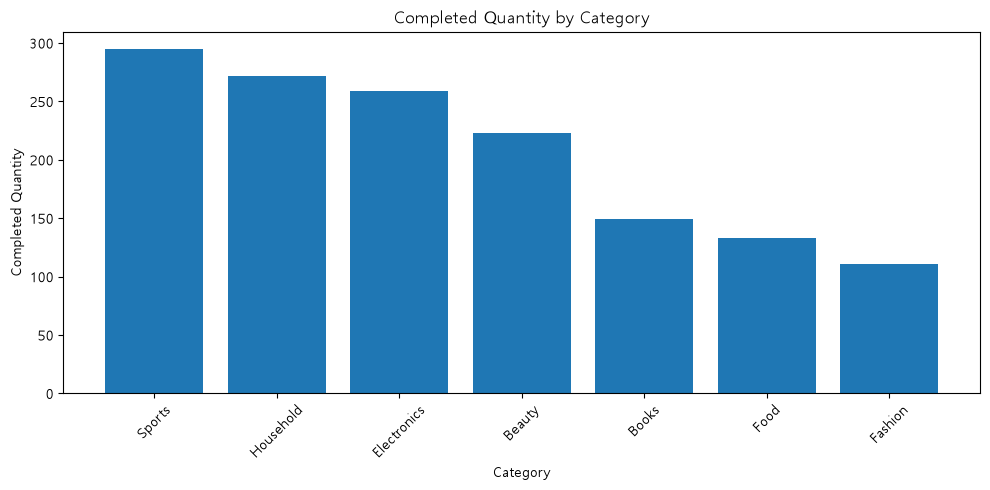

In [111]:
# 과제 1. 카테고리별 판매 수량 막대그래프를 추가로 그려 보세요.
# completed 주문으로 범위를 고정함
assignment_completed_orders = orders.loc[orders['order_status'].eq('completed'), ['order_id', 'order_date', 'customer_id']].copy()
assignment_completed_items = order_items.merge(assignment_completed_orders, on='order_id', how='inner')
assignment_completed_items['order_date'] = pd.to_datetime(assignment_completed_items['order_date'], errors='coerce')
assignment_completed_items = assignment_completed_items.merge(
    products[['product_id', 'category']], on='product_id', how='left'
)
assignment_category_quantity = (
    assignment_completed_items.groupby('category', as_index=False)
    .agg(completed_quantity=('quantity', 'sum'))
    .sort_values('completed_quantity', ascending=False)
)
assignment_category_quantity_total = assignment_category_quantity['completed_quantity'].sum()
assignment_source_quantity_total = assignment_completed_items['quantity'].sum()
print(assignment_category_quantity.to_csv(index=False))
print('category_quantity_total:', assignment_category_quantity_total)
print('completed_source_quantity_total:', assignment_source_quantity_total)
print('category_quantity_difference:', assignment_category_quantity_total - assignment_source_quantity_total)
print('category_missing_count:', assignment_completed_items['category'].isna().sum())

plt.rcParams['font.family'] = 'Malgun Gothic'
assignment_category_quantity['display_category'] = assignment_category_quantity['category'].map({'스포츠': 'Sports', '생활용품': 'Household', '전자기기': 'Electronics', '뷰티': 'Beauty', '도서': 'Books', '식품': 'Food', '패션': 'Fashion'}).fillna(assignment_category_quantity['category'])
plt.figure(figsize=(10, 5))
plt.bar(assignment_category_quantity['display_category'], assignment_category_quantity['completed_quantity'])
plt.title('Completed Quantity by Category')
plt.xlabel('Category')
plt.ylabel('Completed Quantity')
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'ch07_assignment_category_quantity.png', dpi=150, bbox_inches='tight')
plt.show()


payment_method,order_count
kakao_pay,79
naver_pay,77
bank_transfer,74
card,70

payment_method_missing_count: 0
payment_count_total: 300
orders_row_total: 300
payment_count_difference: 0


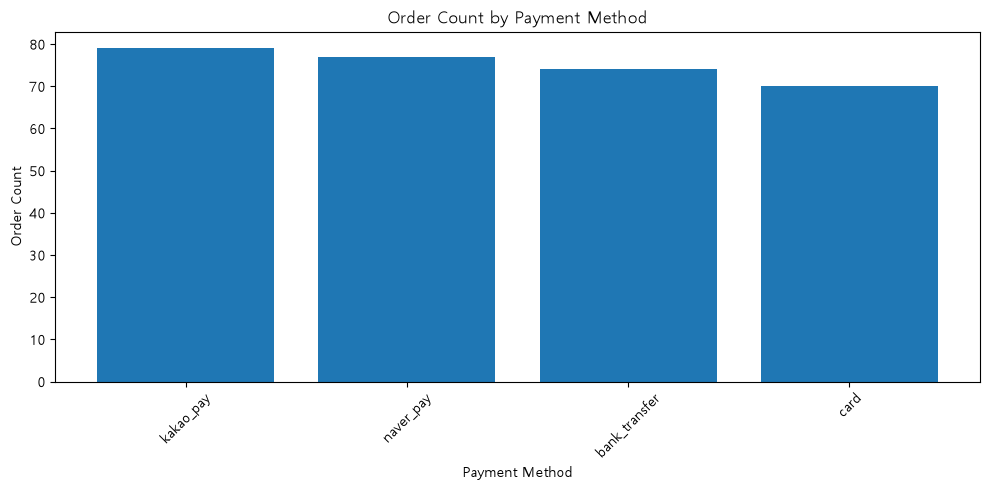

In [112]:
# 과제 2. 결제수단별 주문 수 막대그래프를 그려 보세요.
assignment_payment_counts = (
    orders['payment_method'].value_counts(dropna=False)
    .rename_axis('payment_method').reset_index(name='order_count')
)
assignment_payment_total = assignment_payment_counts['order_count'].sum()
print(assignment_payment_counts.to_csv(index=False))
print('payment_method_missing_count:', orders['payment_method'].isna().sum())
print('payment_count_total:', assignment_payment_total)
print('orders_row_total:', len(orders))
print('payment_count_difference:', assignment_payment_total - len(orders))

plt.figure(figsize=(10, 5))
plt.bar(assignment_payment_counts['payment_method'].fillna('missing').astype(str), assignment_payment_counts['order_count'])
plt.title('Order Count by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Order Count')
plt.ylim(bottom=0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'ch07_assignment_payment_method_count.png', dpi=150, bbox_inches='tight')
plt.show()


customer_count: 150
age_missing_count: 0
count    150.000000
mean      42.086667
std       15.613166
min       19.000000
25%       29.000000
50%       40.000000
75%       57.000000
max       69.000000


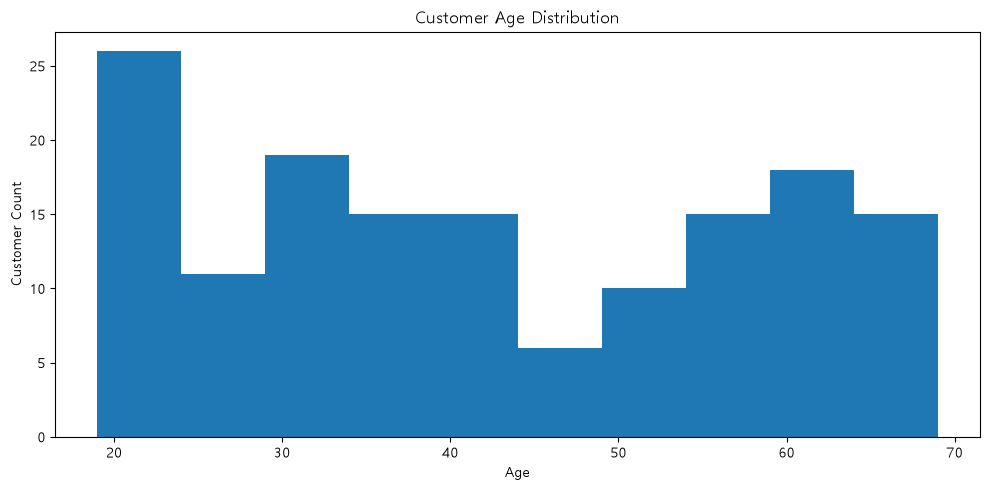

In [113]:
# 과제 3. 고객 나이 분포 히스토그램을 그려 보세요.
assignment_age = customers['age'].dropna()
print('customer_count:', len(customers))
print('age_missing_count:', customers['age'].isna().sum())
print(assignment_age.describe().to_string())

plt.figure(figsize=(10, 5))
plt.hist(assignment_age, bins=10)
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.show()


order_month,order_count
2025-07,8
2025-08,18
2025-09,13
2025-10,26
2025-11,12
2025-12,14
2026-01,22
2026-02,17
2026-03,14
2026-04,23
2026-05,11
2026-06,4
2026-07,2

monthly_completed_order_total: 184
completed_order_total: 184
monthly_order_difference: 0


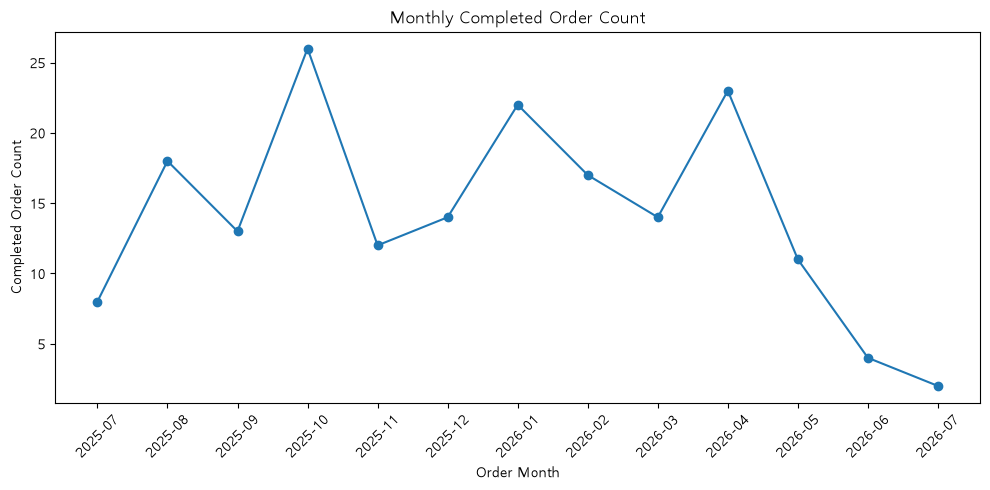

In [114]:
# 과제 4. 월별 주문 수 선 그래프를 그려 보세요.
# 완료 주문의 시간 흐름을 비교하기 위해 completed 주문만 사용한다.
assignment_monthly_order_count = (
    assignment_completed_orders.assign(
        order_date=lambda frame: pd.to_datetime(frame['order_date'], errors='coerce')
    )
    .dropna(subset=['order_date'])
    .assign(order_month=lambda frame: frame['order_date'].dt.to_period('M').astype(str))
    .groupby('order_month', as_index=False)
    .agg(order_count=('order_id', 'nunique'))
    .sort_values('order_month')
)
assignment_monthly_order_total = assignment_monthly_order_count['order_count'].sum()
print(assignment_monthly_order_count.to_csv(index=False))
print('monthly_completed_order_total:', assignment_monthly_order_total)
print('completed_order_total:', assignment_completed_orders['order_id'].nunique())
print('monthly_order_difference:', assignment_monthly_order_total - assignment_completed_orders['order_id'].nunique())

plt.figure(figsize=(10, 5))
plt.plot(assignment_monthly_order_count['order_month'], assignment_monthly_order_count['order_count'], marker='o')
plt.title('Monthly Completed Order Count')
plt.xlabel('Order Month')
plt.ylabel('Completed Order Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


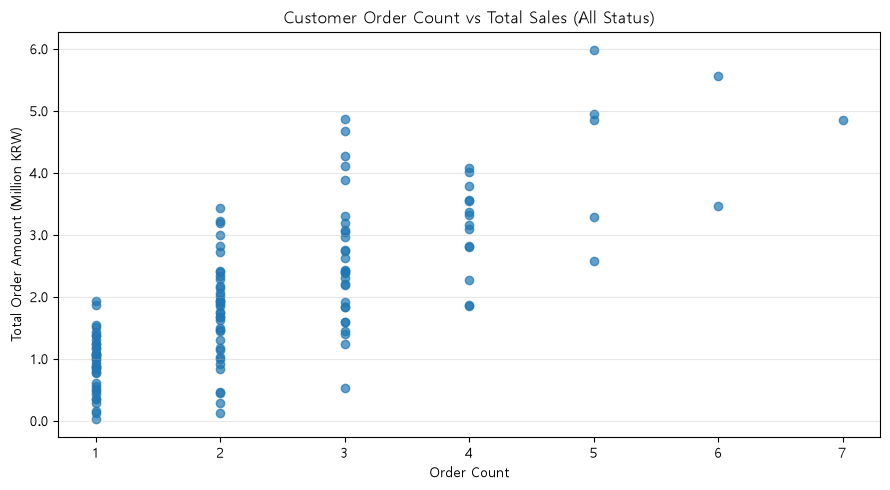

In [115]:
# 과제 5. 고객별 주문 횟수와 총 구매 금액의 관계를 산점도로 그려 보세요.
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    customer_sales['order_count'],
    customer_sales['total_sales'],
    alpha=0.7,
)

ax.set_title('Customer Order Count vs Total Sales (All Status)')
ax.set_xlabel('Order Count')
ax.set_ylabel('Total Order Amount (Million KRW)')

# y축 금액을 백만 원 단위로 표시
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, _: f'{value / 1_000_000:,.1f}')
)

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / 'ch07_customer_order_count_sales_scatter.png',
    dpi=150,
    bbox_inches='tight',
)

plt.show()

## 22. 정리

이번 장에서는 다음 내용을 실습했습니다.

- 분석 질문에 맞는 그래프 선택
- matplotlib 기본 구조와 한글 폰트 설정
- 시각화를 위한 집계 데이터 준비
- 카테고리별 매출 막대그래프
- 월별 매출 선 그래프
- 상품 가격 분포 히스토그램
- 상품 가격과 판매 수량 산점도
- 구매 금액 상위 고객 가로 막대그래프와 익명화
- 주문 상태별 주문 수 막대그래프
- 그래프 파일 저장과 시각화 요약 보고서 작성
- `src/visualization.py`와 `scripts/run_visualization.py`로 반복 실행 가능한 구조 만들기

다음 장에서는 지금까지 배운 데이터 불러오기, 전처리, EDA, 시각화를 종합하여 중간 실습 프로젝트를 수행합니다.


## 6. Chapter 07 최종 판단
### 가장 중요한 그래프 1개와 이유
카테고리별 주문 금액 막대그래프가 가장 중요하다고 생각했다. 같은 범위에서 카테고리별 금액 차이를 바로 비교할 수 있기 때문이다. 전체 금액과 카테고리별 합계가 일치하는지도 확인했다.

### 그래프가 보여 준 사실
주문 금액이 큰 순서대로 스포츠, 뷰티, 전자기기, 생활용품, 식품, 도서, 패션 순이었다. 스포츠는 50174000원으로 가장 컸고 패션은 23801000원으로 가장 작았다. 두 카테고리의 차이는 26373000원이었고 스포츠는 패션의 약 2.1배였다. 다만 실제 금액 단위는 원이지만 그래프에서는 큰 숫자를 표시하면서 e 표기가 사용되었다(이는 후에 원 표기로 수정하였다).

### 그래프만으로 말할 수 없는 것
주문 금액이 크다고 고객 선호도나 수익성, 만족도도 높다고 볼 수는 없다. 총 주문 금액에는 판매 수량과 상품 단가가 함께 반영된다. 따라서 판매량이 많아서 금액이 큰 것인지, 상품 가격이 높아서 그런 것인지는 이 그래프만으로 알 수 없다. 원가, 할인, 반품과 취소, 재고, 상품 수, 상품 노출 조건도 그래프에 포함되지 않았다. 실제 수익성이나 금액 차이의 원인을 확인하려면 다른 지표를 추가로 봐야 한다.

### 시각화에서 가장 주의해야 한다고 느낀 점 
그래프에서는 축의 범위와 단위를 잘 확인해야 한다. 축의 시작점을 다르게 잡으면 실제 차이보다 크거나 작게 보일 수 있다. 특히 막대그래프는 막대 길이로 값을 비교하기 때문에 y축을 0부터 시작하는 것이 중요하다. 단위 표시도 중요했다. 이번 그래프의 금액 단위는 원이지만 큰 숫자가 e 표기로 표시되어 실제 금액을 바로 읽기 어려웠다. 따라서 축에 단위를 표시하고 숫자 형식도 확인할 필요가 있다. 또한 히스토그램은 bins 설정에 따라서도 모양이 달라질 수 있다. 구간을 어떻게 나누느냐에 따라 특정 가격대가 많거나 적게 보일 수 있다. 그래서 한 가지 bins 설정만 보고 분포의 특징을 단정하면 안된다. 

### 다음 분석에서 확인할 질문
다음에는 카테고리별 판매 수량, 평균 단가, 주문 수, 상품 수를 각각 비교한다. 스포츠의 높은 주문 금액이 어떤 지표와 함께 나타나는지 확인하기 위해서다. 판매 수량이 많은지, 평균 단가가 높은지, 주문 수나 상품 수에서도 차이가 있는지 나누어 살펴볼 것이다.

## 최종 체크
- [x] 그래프와 수치를 교차 검증했습니다.
- [x] 관찰과 해석을 구분했습니다.
- [x] 업무적 의미와 한계를 작성했습니다.
- [x] 최종 Notebook URL을 제출합니다.